In [1]:
!pip -q install yfinance tqdm



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, math, random
from dataclasses import dataclass
from typing import Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import yfinance as yf

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything(42)
print("Device:", device)


Device: cuda


In [45]:
TICKER = "SPY"

START_DATE = "2010-01-01"
END_DATE_EXCLUSIVE = "2024-01-01"  

SEQ_LEN = 64
TRAIN_RATIO = 0.9

BATCH_SIZE = 128
LR = 1e-4
EPOCHS = 200

# Sampling
N_GEN = 5000
ODE_STEPS = 100
SOLVER = "heun"

OUTDIR = "fm_out_spy"
os.makedirs(OUTDIR, exist_ok=True)


In [4]:
df = yf.download(TICKER, start=START_DATE, end=END_DATE_EXCLUSIVE, progress=False, auto_adjust=False)
df = df.reset_index()

display(df.head())
print("Columns:", list(df.columns))
print("Date range:", df["Date"].min(), "→", df["Date"].max())


Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,SPY,SPY,SPY,SPY,SPY,SPY
0,2010-01-04,85.027962,113.330002,113.389999,111.510002,112.370003,118944600
1,2010-01-05,85.253044,113.629997,113.680000,112.849998,113.260002,111579900
2,2010-01-06,85.313042,113.709999,113.989998,113.430000,113.519997,116074400
3,2010-01-07,85.673172,114.190002,114.330002,113.180000,113.500000,131091100
4,2010-01-08,85.958282,114.570000,114.620003,113.660004,113.889999,126402800


Columns: [('Date', ''), ('Adj Close', 'SPY'), ('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]
Date range: 2010-01-04 00:00:00 → 2023-12-29 00:00:00


In [5]:
if "Adj Close" not in df.columns:
    raise ValueError("ستون 'Adj Close' در داده وجود ندارد. ستون‌های موجود: " + str(list(df.columns)))

adj = df["Adj Close"].astype(float)
logp = np.log(adj.values)
logret = logp[1:] - logp[:-1]  # r_t = log(P_t) - log(P_{t-1})
logret = logret[np.isfinite(logret)].astype(np.float32)

print("Num returns:", len(logret))
print("Return stats (raw): mean=%.6f std=%.6f" % (logret.mean(), logret.std()))

def make_overlapping_sequences(x: np.ndarray, seq_len: int) -> np.ndarray:
    T = len(x)
    if T < seq_len:
        raise ValueError(f"Time series too short: len={T} < seq_len={seq_len}")
    N = T - seq_len + 1
    return np.stack([x[i:i+seq_len] for i in range(N)], axis=0).astype(np.float32)

seqs = make_overlapping_sequences(logret, SEQ_LEN)
print("Sequences shape:", seqs.shape)  # [N, 64]

n = seqs.shape[0]
n_train = int(n * TRAIN_RATIO)
train_raw = seqs[:n_train]
test_raw  = seqs[n_train:]

mean_train = float(train_raw.mean())
std_train  = float(train_raw.std() + 1e-8)

train = ((train_raw - mean_train) / std_train).astype(np.float32)
test  = ((test_raw  - mean_train) / std_train).astype(np.float32)

print(f"Train: {train.shape} | Test: {test.shape}")
print("Standardization: mean=%.6f std=%.6f" % (mean_train, std_train))


Num returns: 3521
Return stats (raw): mean=0.000482 std=0.010947
Sequences shape: (3458, 64)
Train: (3112, 64) | Test: (346, 64)
Standardization: mean=0.000480 std=0.010951


In [6]:
# -----------------------
# Dataset / DataLoader
# -----------------------
class SeqDataset(Dataset):
    def __init__(self, sequences: np.ndarray):
        self.x = torch.from_numpy(sequences)  # [N, L]
    def __len__(self):
        return self.x.shape[0]
    def __getitem__(self, idx):
        return self.x[idx]

train_ds = SeqDataset(train)
test_ds  = SeqDataset(test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

next(iter(train_loader)).shape


torch.Size([512, 64])

In [23]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(torch.linspace(0, math.log(10000), half, device=t.device))
        args = t * freqs[None, :]  # [B, half]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb

class FlowMLP(nn.Module):
    def __init__(self, seq_len: int = 64, t_emb_dim: int = 128, hidden: int = 512, depth: int = 4, dropout: float = 0.0):
        super().__init__()
        self.t_embed = SinusoidalTimeEmbedding(t_emb_dim)

        layers = []
        in_dim = seq_len + t_emb_dim
        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else hidden, hidden))
            layers.append(nn.SiLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden, seq_len))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        te = self.t_embed(t)
        h = torch.cat([x, te], dim=-1)
        return self.net(h)

model = FlowMLP(seq_len=SEQ_LEN, t_emb_dim=128, hidden=512, depth=4, dropout=0.0).to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)

sum(p.numel() for p in model.parameters())


919616

In [24]:
@torch.no_grad()
def make_flow_matching_batch(x_data: torch.Tensor):
    """
    z ~ N(0,I),  t ~ U[0,1]
    x_t = (1-t) z + t x
    u_t = d/dt x_t = x - z
    """
    B, L = x_data.shape
    z = torch.randn(B, L, device=x_data.device)
    t = torch.rand(B, 1, device=x_data.device)
    x_t = (1.0 - t) * z + t * x_data
    u = x_data - z
    return x_t, t, u


In [25]:
def run_epoch(model: nn.Module, loader: DataLoader, optim: torch.optim.Optimizer, train: bool):
    model.train() if train else model.eval()
    total = 0.0
    n = 0

    pbar = tqdm(loader, desc=("train" if train else "test"), leave=False)
    for x in pbar:
        x = x.to(device, dtype=torch.float32)

        x_t, t, u = make_flow_matching_batch(x)

        with torch.set_grad_enabled(train):
            v = model(x_t, t)
            loss = F.mse_loss(v, u)

            if train:
                optim.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()

        total += float(loss.item()) * x.size(0)
        n += x.size(0)
        pbar.set_postfix(loss=float(loss.item()))

    return total / max(n, 1)

train_losses, test_losses = [], []
for epoch in range(EPOCHS):
    tr = run_epoch(model, train_loader, optim, train=True)
    te = run_epoch(model, test_loader,  optim, train=False)
    train_losses.append(tr)
    test_losses.append(te)
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | train={tr:.6f} | test={te:.6f}")

# ذخیره checkpoint
ckpt_path = os.path.join(OUTDIR, "flow_matching_spy.pt")
torch.save({
    "model_state": model.state_dict(),
    "seq_len": SEQ_LEN,
    "mean_train": mean_train,
    "std_train": std_train,
    "config": {
        "BATCH_SIZE": BATCH_SIZE,
        "LR": LR,
        "EPOCHS": EPOCHS,
        "ODE_STEPS": ODE_STEPS,
        "SOLVER": SOLVER,
        "N_GEN": N_GEN,
        "START_DATE": START_DATE,
        "END_DATE_EXCLUSIVE": END_DATE_EXCLUSIVE,
    }
}, ckpt_path)
print("Saved:", ckpt_path)


Epoch 001/200 | train=1.995445 | test=2.076865


Epoch 002/200 | train=1.996979 | test=2.069103


Epoch 003/200 | train=1.998588 | test=2.072346


Epoch 004/200 | train=1.999667 | test=2.064043


Epoch 005/200 | train=2.002880 | test=2.087870


...

Epoch 196/200 | train=1.761523 | test=1.917376


Epoch 197/200 | train=1.763684 | test=1.893625


Epoch 198/200 | train=1.751483 | test=1.933528


Epoch 199/200 | train=1.743764 | test=1.888409


Epoch 200/200 | train=1.761567 | test=1.935252
Saved: fm_out_spy\flow_matching_spy.pt


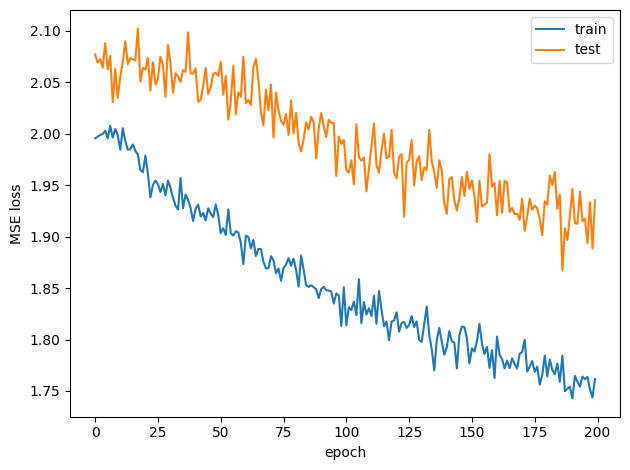

In [26]:
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "loss_curve.png"), dpi=150)
plt.show()


In [58]:
@torch.no_grad()
def sample_ode_euler(model: nn.Module, n_samples: int, seq_len: int, n_steps: int):
    model.eval()
    x = torch.randn(n_samples, seq_len, device=device)
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.full((n_samples, 1), k * dt, device=device)
        v = model(x, t)
        x = x + dt * v
    return x

@torch.no_grad()
def sample_ode_heun(model: nn.Module, n_samples: int, seq_len: int, n_steps: int):
    model.eval()
    temprature = 0.8
    x = torch.randn(n_samples, seq_len, device=device) * temprature
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t0 = torch.full((n_samples, 1), k * dt, device=device)
        v0 = model(x, t0)
        x_pred = x + dt * v0
        t1 = torch.full((n_samples, 1), (k + 1) * dt, device=device)
        v1 = model(x_pred, t1)
        x = x + 0.5 * dt * (v0 + v1)
    return x

# تولید داده مصنوعی
if SOLVER.lower() == "euler":
    gen_norm_t = sample_ode_euler(model, N_GEN, SEQ_LEN, ODE_STEPS)
else:
    gen_norm_t = sample_ode_heun(model, N_GEN, SEQ_LEN, ODE_STEPS)

gen_norm = gen_norm_t.detach().cpu().numpy().astype(np.float32)
gen_denorm = gen_norm * std_train + mean_train

print("Generated:", gen_norm.shape, gen_denorm.shape)


Generated: (5000, 64) (5000, 64)


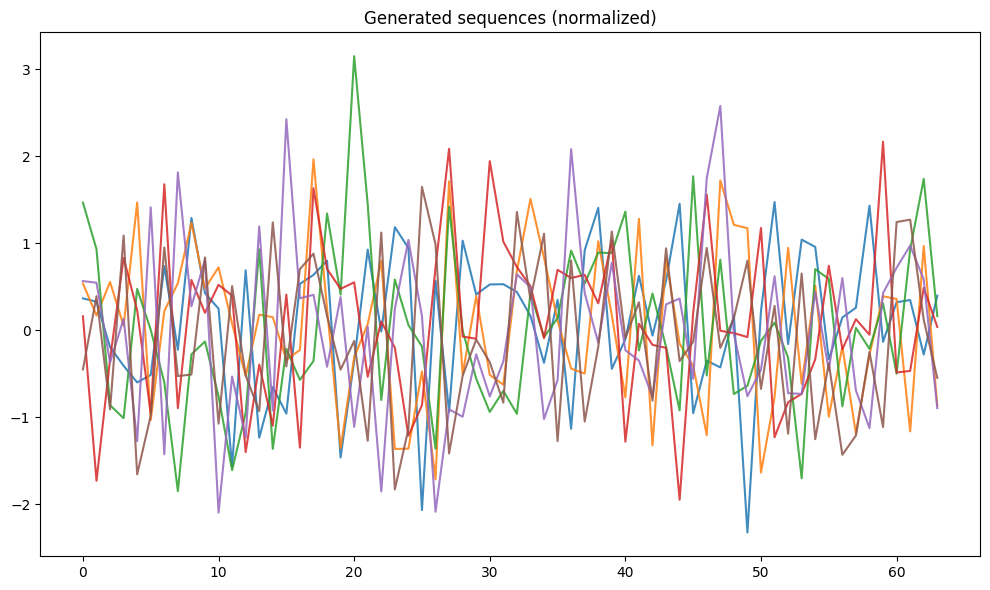

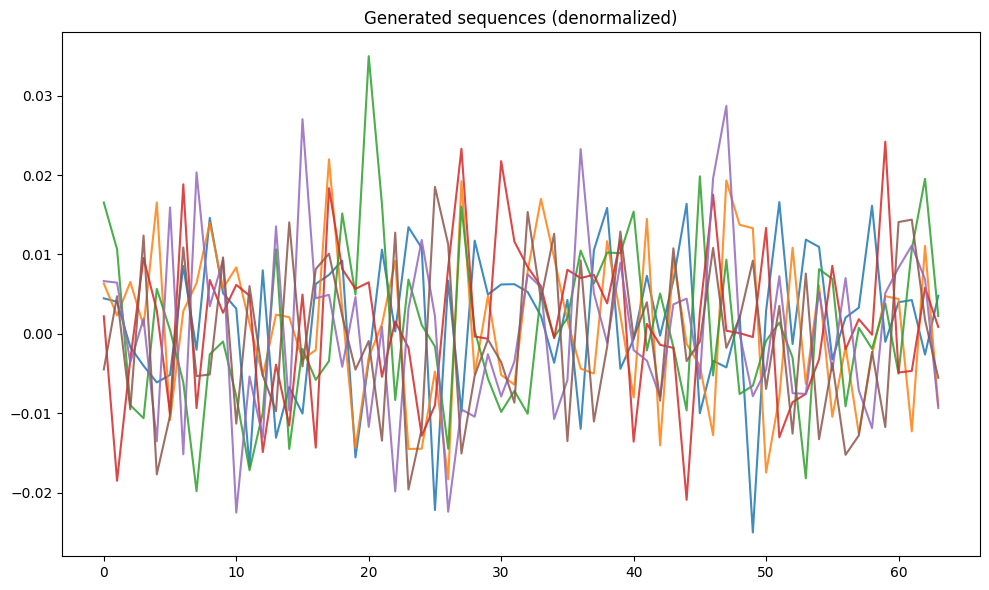

In [59]:
def plot_some_sequences(arr: np.ndarray, title: str, k: int = 6):
    k = min(k, arr.shape[0])
    plt.figure(figsize=(10, 6))
    for i in range(k):
        plt.plot(arr[i], alpha=0.85)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_some_sequences(gen_norm, "Generated sequences (normalized)")
plot_some_sequences(gen_denorm, "Generated sequences (denormalized)")


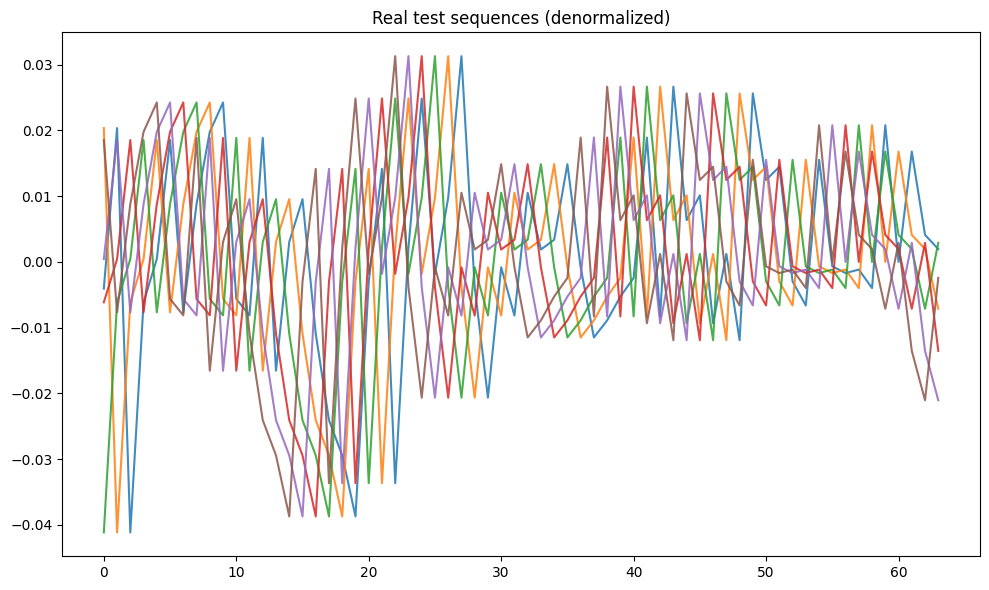

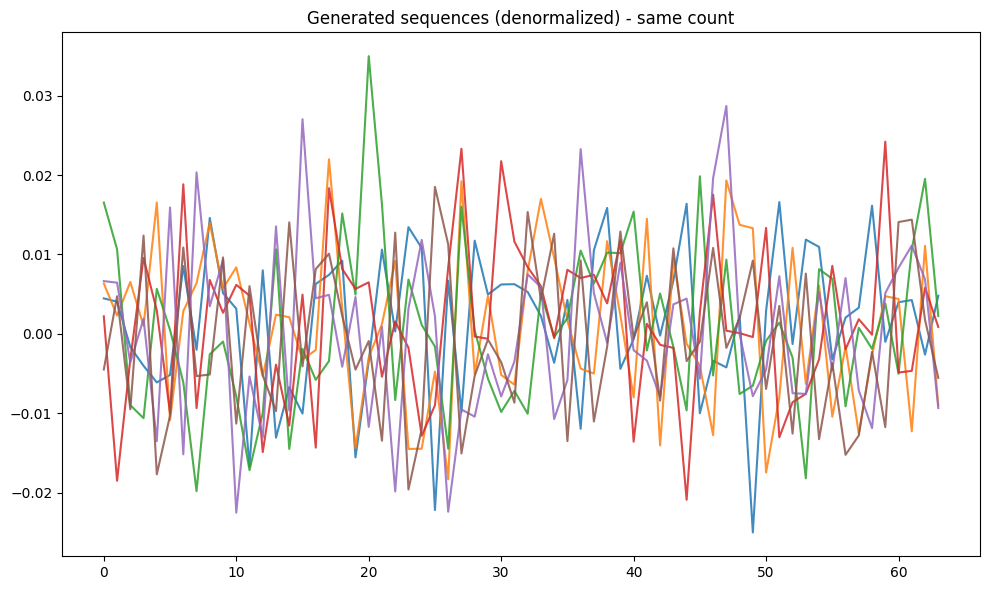

In [60]:
real_test_norm = test[:min(len(test), 2000)]
real_test_denorm = real_test_norm * std_train + mean_train

plot_some_sequences(real_test_denorm, "Real test sequences (denormalized)")
plot_some_sequences(gen_denorm[:min(len(gen_denorm), len(real_test_denorm))], "Generated sequences (denormalized) - same count")


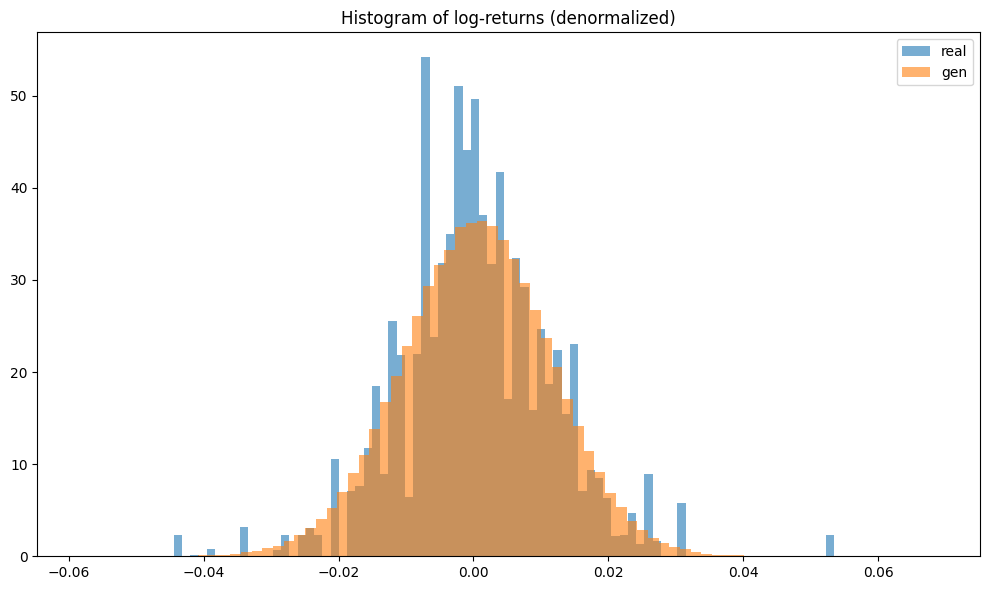

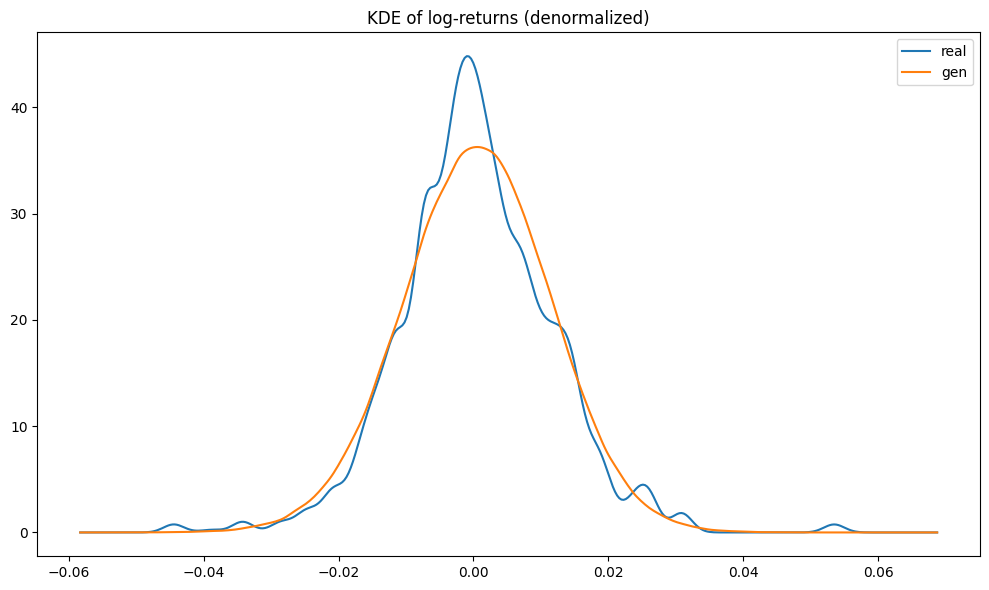

In [61]:
real_vals = real_test_denorm.reshape(-1)
gen_vals  = gen_denorm.reshape(-1)

# Histogram
plt.figure(figsize=(10,6))
plt.hist(real_vals, bins=80, density=True, alpha=0.6, label="real")
plt.hist(gen_vals,  bins=80, density=True, alpha=0.6, label="gen")
plt.title("Histogram of log-returns (denormalized)")
plt.legend()
plt.tight_layout()
plt.show()

# KDE
grid = np.linspace(min(real_vals.min(), gen_vals.min()), max(real_vals.max(), gen_vals.max()), 400).astype(np.float32)

try:
    from scipy.stats import gaussian_kde
    kde_r = gaussian_kde(real_vals)(grid)
    kde_g = gaussian_kde(gen_vals)(grid)
except Exception:
    # KDE
    def kde_manual(x, grid, bw):
        x = x.reshape(-1, 1)
        grid = grid.reshape(1, -1)
        z = (grid - x) / (bw + 1e-12)
        k = np.exp(-0.5 * z**2) / (math.sqrt(2*math.pi) * (bw + 1e-12))
        return k.mean(axis=0)

    rs = real_vals[np.random.choice(len(real_vals), size=min(20000, len(real_vals)), replace=False)]
    gs = gen_vals[np.random.choice(len(gen_vals), size=min(20000, len(gen_vals)), replace=False)]
    bw = 0.3 * float(np.std(rs) + 1e-12)
    kde_r = kde_manual(rs, grid, bw)
    kde_g = kde_manual(gs, grid, bw)

plt.figure(figsize=(10,6))
plt.plot(grid, kde_r, label="real")
plt.plot(grid, kde_g, label="gen")
plt.title("KDE of log-returns (denormalized)")
plt.legend()
plt.tight_layout()
plt.show()


In [62]:
def basic_stats(vals_1d: np.ndarray):
    mu = float(np.mean(vals_1d))
    var = float(np.var(vals_1d))
    vol = float(np.std(vals_1d))
    return mu, var, vol

real_mu, real_var, real_vol = basic_stats(real_vals)
gen_mu,  gen_var,  gen_vol  = basic_stats(gen_vals)

print("Real: mean=%.6f var=%.6f vol=%.6f" % (real_mu, real_var, real_vol))
print("Gen : mean=%.6f var=%.6f vol=%.6f" % (gen_mu,  gen_var,  gen_vol))


Real: mean=0.000400 var=0.000128 vol=0.011293
Gen : mean=0.000462 var=0.000122 vol=0.011059


SWD: 0.0011855195648422523
Autocorr stats: {'autocorr_mean_real': -0.01057236548513174, 'autocorr_mean_gen': -0.013431016355752945, 'autocorr_mean_absdiff': 0.0028586508706212044, 'autocorr_mse': 0.0023315134458243847}


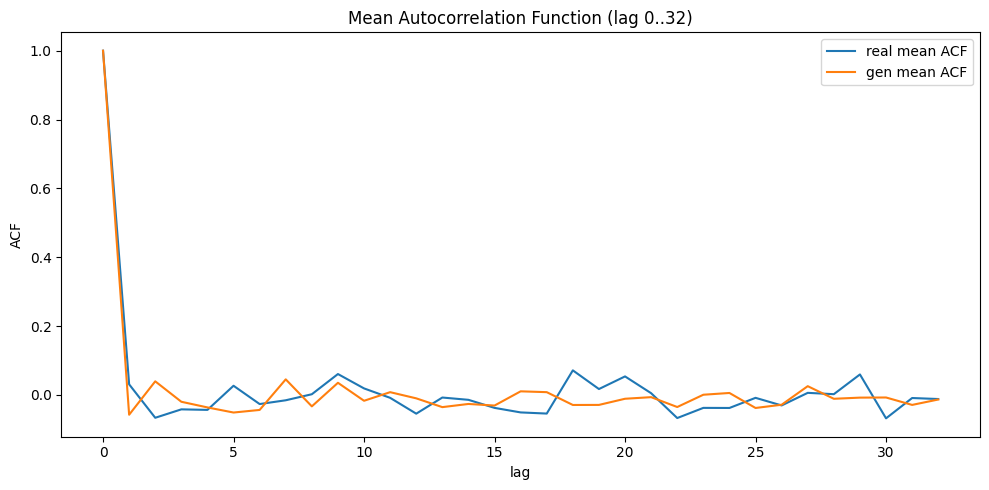

In [63]:
def sliced_wasserstein_distance(X: np.ndarray, Y: np.ndarray, n_proj: int = 128, seed: int = 0) -> float:
    rng = np.random.default_rng(seed)
    N, D = X.shape
    M, D2 = Y.shape
    assert D == D2
    dirs = rng.normal(size=(n_proj, D)).astype(np.float32)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-12

    swds = []
    for i in range(n_proj):
        u = dirs[i]
        x1 = np.sort(X @ u)
        y1 = np.sort(Y @ u)
        K = min(len(x1), len(y1))
        swds.append(float(np.mean(np.abs(x1[:K] - y1[:K]))))
    return float(np.mean(swds))

def autocorr_1d(x: np.ndarray, max_lag: int = 32) -> np.ndarray:
    x = x.astype(np.float64)
    x = x - x.mean()
    denom = np.dot(x, x) + 1e-12
    acf = [1.0]
    for lag in range(1, max_lag + 1):
        acf.append(float(np.dot(x[:-lag], x[lag:]) / denom))
    return np.array(acf, dtype=np.float32)

def autocorr_stats(real: np.ndarray, gen: np.ndarray, max_lag: int = 32) -> Dict[str, float]:
    real_acfs = np.stack([autocorr_1d(s, max_lag=max_lag) for s in real], axis=0)
    gen_acfs  = np.stack([autocorr_1d(s, max_lag=max_lag) for s in gen], axis=0)

    real_mean_acf = real_acfs.mean(axis=0)
    gen_mean_acf  = gen_acfs.mean(axis=0)

    rm = float(real_mean_acf[1:].mean())
    gm = float(gen_mean_acf[1:].mean())
    mse = float(np.mean((real_mean_acf[1:] - gen_mean_acf[1:]) ** 2))
    return {
        "autocorr_mean_real": rm,
        "autocorr_mean_gen": gm,
        "autocorr_mean_absdiff": abs(rm - gm),
        "autocorr_mse": mse,
    }

n_eval = min(real_test_denorm.shape[0], gen_denorm.shape[0], 5000)
X = real_test_denorm[:n_eval].astype(np.float32)
Y = gen_denorm[:n_eval].astype(np.float32)

swd = sliced_wasserstein_distance(X, Y, n_proj=128, seed=0)
ac = autocorr_stats(X, Y, max_lag=32)

print("SWD:", swd)
print("Autocorr stats:", ac)

real_mean_acf = np.stack([autocorr_1d(s, 32) for s in X], axis=0).mean(axis=0)
gen_mean_acf  = np.stack([autocorr_1d(s, 32) for s in Y], axis=0).mean(axis=0)

plt.figure(figsize=(10,5))
plt.plot(real_mean_acf, label="real mean ACF")
plt.plot(gen_mean_acf, label="gen mean ACF")
plt.title("Mean Autocorrelation Function (lag 0..32)")
plt.xlabel("lag")
plt.ylabel("ACF")
plt.legend()
plt.tight_layout()
plt.show()


In [64]:
report = {
    "train_loss_last": float(train_losses[-1]) if len(train_losses) else None,
    "test_loss_last": float(test_losses[-1]) if len(test_losses) else None,
    "basic_real_mean": real_mu,
    "basic_real_var": real_var,
    "basic_real_vol": real_vol,
    "basic_gen_mean": gen_mu,
    "basic_gen_var": gen_var,
    "basic_gen_vol": gen_vol,
    "SWD": float(swd),
    **ac,
    "standardize_mean": float(mean_train),
    "standardize_std": float(std_train),
    "ticker": TICKER,
    "start_date": START_DATE,
    "end_date_exclusive": END_DATE_EXCLUSIVE,
    "seq_len": SEQ_LEN,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "epochs": EPOCHS,
    "solver": SOLVER,
    "ode_steps": ODE_STEPS,
    "n_gen": N_GEN,
}

report_path = os.path.join(OUTDIR, "metrics_report.csv")
pd.Series(report).to_csv(report_path)
print("Saved report:", report_path)

Saved report: fm_out_spy\metrics_report.csv


{'train_loss_last': 1.7615669171015422,
 'test_loss_last': 1.9352515935897827,
 'basic_real_mean': 0.00040004277252592146,
 'basic_real_var': 0.0001275379181606695,
 'basic_real_vol': 0.011293268762528896,
 'basic_gen_mean': 0.0004623627755790949,
 'basic_gen_var': 0.00012229334970470518,
 'basic_gen_vol': 0.011058632284402847,
 'SWD': 0.0011855195648422523,
 'autocorr_mean_real': -0.01057236548513174,
 'autocorr_mean_gen': -0.013431016355752945,
 'autocorr_mean_absdiff': 0.0028586508706212044,
 'autocorr_mse': 0.0023315134458243847,
 'standardize_mean': 0.00047958880895748734,
 'standardize_std': 0.010951113642582893,
 'ticker': 'SPY',
 'start_date': '2010-01-01',
 'end_date_exclusive': '2024-01-01',
 'seq_len': 64,
 'batch_size': 128,
 'lr': 0.0001,
 'epochs': 200,
 'solver': 'heun',
 'ode_steps': 100,
 'n_gen': 5000}

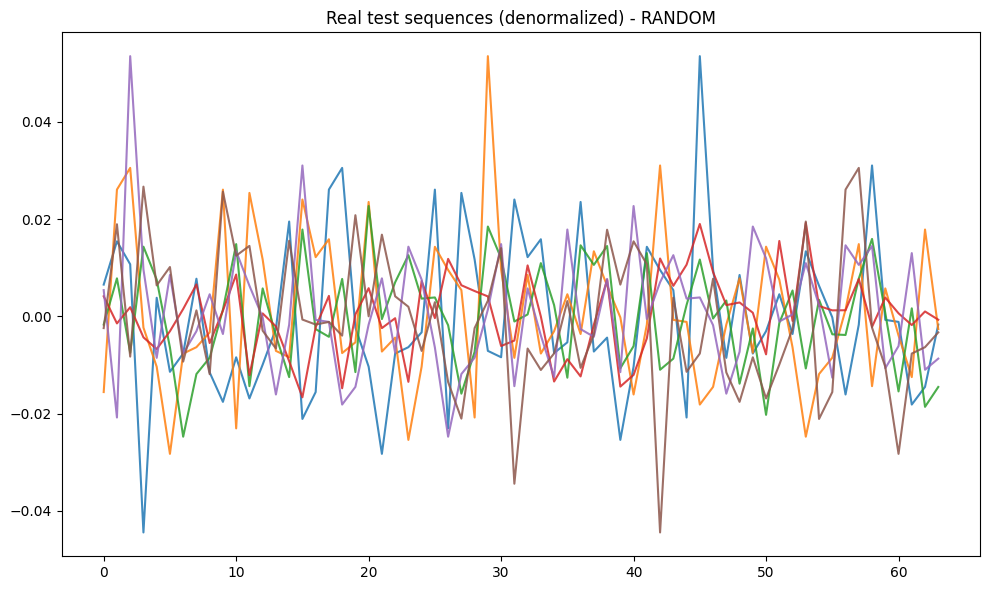

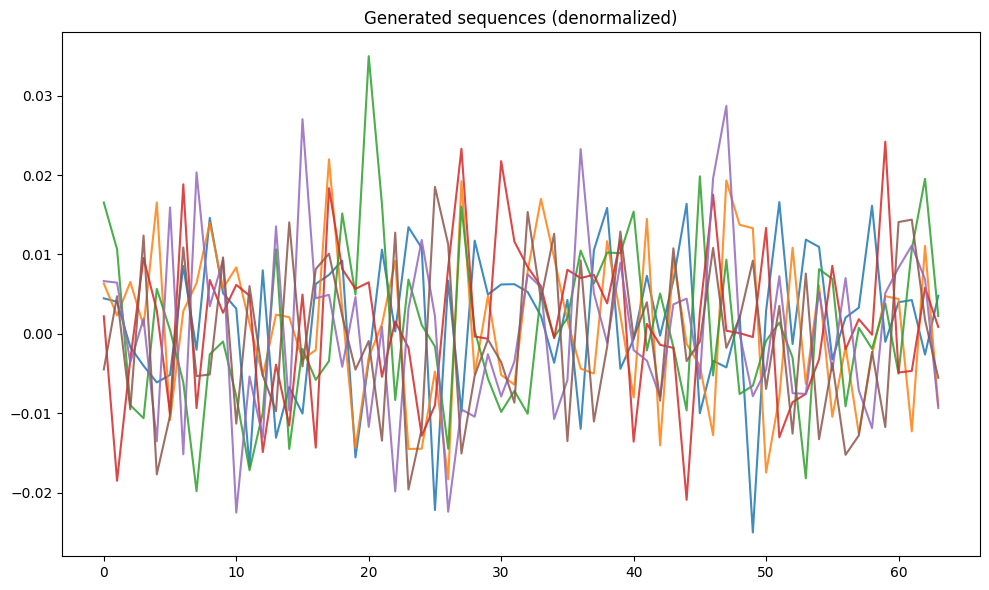

In [65]:
k = 6
idx = np.random.choice(len(test), size=k, replace=False)
real_rand = test[idx] * std_train + mean_train

plot_some_sequences(real_rand, "Real test sequences (denormalized) - RANDOM")
plot_some_sequences(gen_denorm[:k], "Generated sequences (denormalized)")


In [67]:
print("real_norm std:", real_test_norm.reshape(-1).std())
print("gen_norm  std:", gen_norm.reshape(-1).std())


real_norm std: 1.0312438
gen_norm  std: 1.009818


Finding the best value for temperature

In [57]:
temps = [0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
target_std = real_test_denorm.reshape(-1).std()

best = []
for temp in temps:
    with torch.no_grad():
        if SOLVER.lower() == "euler":
            x = torch.randn(N_GEN, SEQ_LEN, device=device) * temp
            dt = 1.0 / ODE_STEPS
            for k in range(ODE_STEPS):
                t = torch.full((N_GEN,1), k*dt, device=device)
                x = x + dt * model(x,t)
            gen = (x.detach().cpu().numpy() * std_train + mean_train).reshape(-1)
        else:
            x = torch.randn(N_GEN, SEQ_LEN, device=device) * temp
            dt = 1.0 / ODE_STEPS
            for k in range(ODE_STEPS):
                t0 = torch.full((N_GEN,1), k*dt, device=device)
                v0 = model(x,t0)
                x_pred = x + dt*v0
                t1 = torch.full((N_GEN,1), (k+1)*dt, device=device)
                v1 = model(x_pred,t1)
                x = x + 0.5*dt*(v0+v1)
            gen = (x.detach().cpu().numpy() * std_train + mean_train).reshape(-1)

    gen_std = gen.std()
    diff = abs(gen_std - target_std)
    print(f"temp={temp:.2f}  gen_std={gen_std:.6f}  diff={diff:.6f}")
    Reina = (temp, gen_std, diff)
    best.append(Reina)

best = sorted(best, key=lambda x: x[2])[0]
print("BEST:", best, "target_std:", target_std)


temp=0.60  gen_std=0.007942  diff=0.003351
temp=0.70  gen_std=0.009452  diff=0.001841
temp=0.75  gen_std=0.010289  diff=0.001004
temp=0.80  gen_std=0.011042  diff=0.000251
temp=0.85  gen_std=0.011914  diff=0.000620
temp=0.90  gen_std=0.012768  diff=0.001475
temp=1.00  gen_std=0.014583  diff=0.003290
BEST: (0.8, 0.011042479, 0.00025078934) target_std: 0.011293269


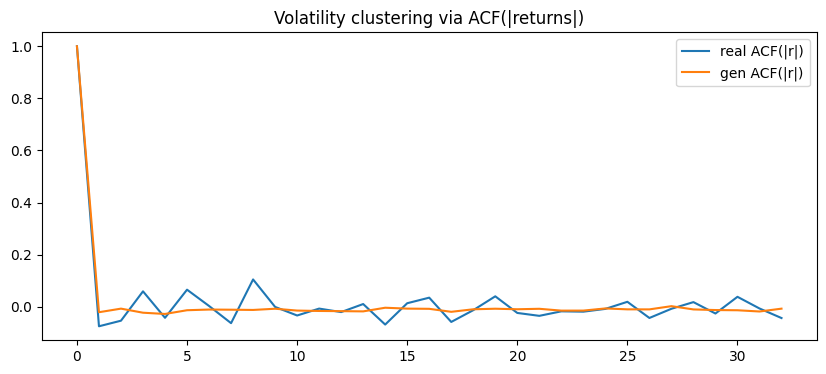

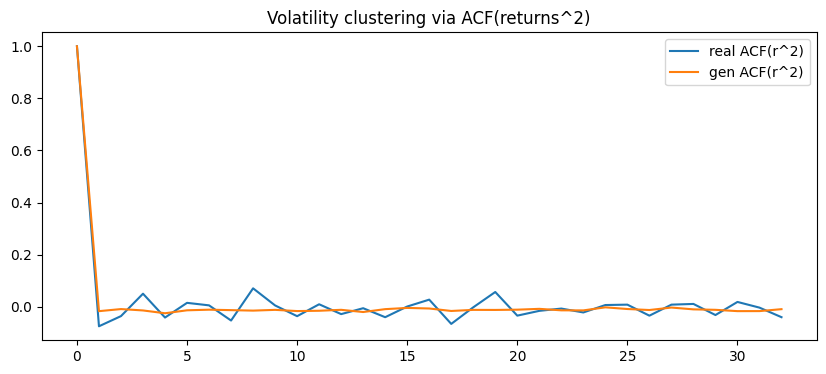

In [68]:
def acf_mean(seqs, max_lag=32, transform=None):
    if transform is not None:
        seqs = transform(seqs)
    acfs = np.stack([autocorr_1d(s, max_lag=max_lag) for s in seqs], axis=0)
    return acfs.mean(axis=0)

X = real_test_denorm[:min(len(real_test_denorm), len(gen_denorm))]
Y = gen_denorm[:len(X)]

real_acf_abs = acf_mean(X, 32, transform=np.abs)
gen_acf_abs  = acf_mean(Y, 32, transform=np.abs)

real_acf_sq  = acf_mean(X, 32, transform=lambda z: z**2)
gen_acf_sq   = acf_mean(Y, 32, transform=lambda z: z**2)

plt.figure(figsize=(10,4))
plt.plot(real_acf_abs, label="real ACF(|r|)")
plt.plot(gen_acf_abs, label="gen ACF(|r|)")
plt.legend(); plt.title("Volatility clustering via ACF(|returns|)")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(real_acf_sq, label="real ACF(r^2)")
plt.plot(gen_acf_sq, label="gen ACF(r^2)")
plt.legend(); plt.title("Volatility clustering via ACF(returns^2)")
plt.show()
